# Step 3 — Results and publication figures

Reads the posterior chains saved by step 2 and turns them into the figures and tables that
carry the interpretation. Nothing is computed here that step 2 did not already produce; this
notebook is about *reading* the result correctly.

## What each figure is for

| Figure | Function | What to look for |
|---|---|---|
| Posterior predictive check | `plot_ppc` | whether the inferred geometry reproduces the observables — **including the ones left out of the likelihood** |
| Marginal posteriors | `plot_marginals` | whether each parameter was constrained, or merely returned its prior |
| Corner plot | `plot_corner` | the parameter degeneracies |
| Ring diagram | `plot_ring_diagram` | what the median geometry actually looks like on the sky |
| Consolidated panel | `plot_results_panel`, `plot_results_panel_inset` | the per-planet summary used in the manuscript |

## How to read these results

**The PPC is the real test, and it is stricter than the fit.** Including an observable in
$\mathcal{L}_{\rm KDE}$ does not guarantee the others are reproduced. A configuration can fit
its own likelihood observables and still mispredict the durations by several minutes — which is
exactly what happens for the simpler parameterisations. The observables *excluded* from the
likelihood are therefore the informative ones: they are an out-of-sample check. $b_{\rm obs}$ is
always out-of-sample. Each panel reports the 1-Wasserstein distance $W_1$ (mean absolute
displacement), the KS $p$-value $p_{\rm KS}$ (null: same parent distribution), and an energy
distance $E$.

**Two degeneracies are structural, not numerical.**

- $f_e$ against $p$: the effective occulting area is
  $A_{\rm eff} = \pi R_p^2 + A_{\rm ring}$, so *any* pair that preserves $A_{\rm eff}$ yields
  an identical transit depth. The sampler explores that iso-depth surface freely, which is why
  fixing $p$ pushes $f_e$ to large values and freeing it pulls $f_e$ back down. Neither is
  "the" answer; the pair is what is constrained.
- $i_R$ against $\theta_R$: the same projected ellipse can be produced by trading inclination
  against azimuth. Adding $T_{14}$ to the likelihood restricts this, because the orientation
  must then also reproduce the contact geometry with the stellar limb.

**A marginal that reproduces its prior means the data said nothing about that parameter.** This
matters most for $i_R$, whose prior $\propto \sin i_R$ already favours edge-on orientations: the
informative quantity is the *departure* from the prior shape, not the shape itself.

**Nuisance-parameter posteriors are model-conditional.** When $b$ and $\rho_{\star,\rm true}$
are sampled, their posteriors may drift away from the external constraints they were given. That
is the model balancing orbital scale against ring geometry — for instance a higher stellar
density compresses the orbital timescale while a larger ring extends the transit through the
outer contacts. Read them as geometric artefacts of the fit, not as a revised measurement of the
star or the orbit.


## 0. Environment and style

In [1]:
# ── Bootstrap: make the sibling packages importable without installation ────
# The pipeline uses three packages that live in the repository, uninstalled:
#   exorings, geotrans   (repo root)      photoring   (pipeline/)
# We locate the repo root and pipeline/ robustly from the current working dir
# (Jupyter / nbconvert / papermill all run notebooks from pipeline/).
import sys, pathlib
_HERE   = pathlib.Path.cwd().resolve()
_cands  = [_HERE, *_HERE.parents]
_NB_DIR = next((c for c in _cands if (c / "photoring").is_dir()), _HERE)
_REPO   = next((c for c in _cands if (c / "exorings").is_dir()), _NB_DIR.parent)
for _p in (str(_REPO), str(_NB_DIR)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root :", _REPO)
print("pipeline  :", _NB_DIR)

repo root : /home/numpaque/AppPR
pipeline  : /home/numpaque/AppPR/pipeline


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import photoring as pr
import photoring.plotting as plot
from photoring.io import load_observables

# Edit STYLE overrides here (e.g. use_latex=True needs a TeX install).
plot.apply_style({"use_latex": False})

## 1. Configuration  ← point at your case / runs

`RUN_TAGS = []` auto-discovers every run in `results/<forward_model>/`, which is usually what
you want after a sweep. List specific tags to restrict the selection — the tag encodes the full
configuration, so the directory is self-describing.


In [3]:
CASE          = "kepler_51"
FORWARD_MODEL = "exorings"          # which results/<model>/ directory to read
RUN_TAGS      = []                   # [] -> auto-discover all runs in that directory
PPC_OBSERVABLES = ["delta", "T14", "T23", "rho_obs", "b_obs"]
PLANETS       = ["b", "d"]           # planets whose TTV observables to overlay

paths = pr.CasePaths(CASE)
paths.ensure_outputs(FORWARD_MODEL)
print("results dir:", paths.results_dir(FORWARD_MODEL))

results dir: /home/numpaque/AppPR/pipeline/kepler_51/results/exorings


## 2. Load runs and TTV observables

Each run is loaded with its metadata and, where the sampling history was persisted, a
reconstructed `dynesty` result object. The TTV observables from step 1 are the reference the
PPC compares against; the independent stellar-density samples are the prior overlay for
$\rho_{\star,\rm true}$.


In [4]:
RUNS = pr.discover_runs(paths.results_dir(FORWARD_MODEL), RUN_TAGS or None)
RUNS_LIST = list(RUNS.values())
print(f"loaded {len(RUNS_LIST)} run(s)")
for r in RUNS_LIST:
    print(f"  {r['tag']}  planet={r['planet']}  lnZ={r['logz']:.2f}  N={len(r['chain'])}")

TTV = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS
       if paths.observables_file(pl).exists()}
try:
    BERGER = np.loadtxt(paths.rho_true_samples) / 1000.0
except Exception:
    BERGER = None

loaded 2 run(s)
  kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE  planet=d  lnZ=2.11  N=15193
  kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE  planet=d  lnZ=1.78  N=14863


## 3. Per-run figures

PPC, marginals with priors, corner, and the ring diagram for every discovered run. Written to
`figures/<type>/` under the case directory, named from the run tag.



== kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE ==


/home/numpaque/AppPR/pipeline/photoring/plotting.py:546: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/ppc/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_ppc.png


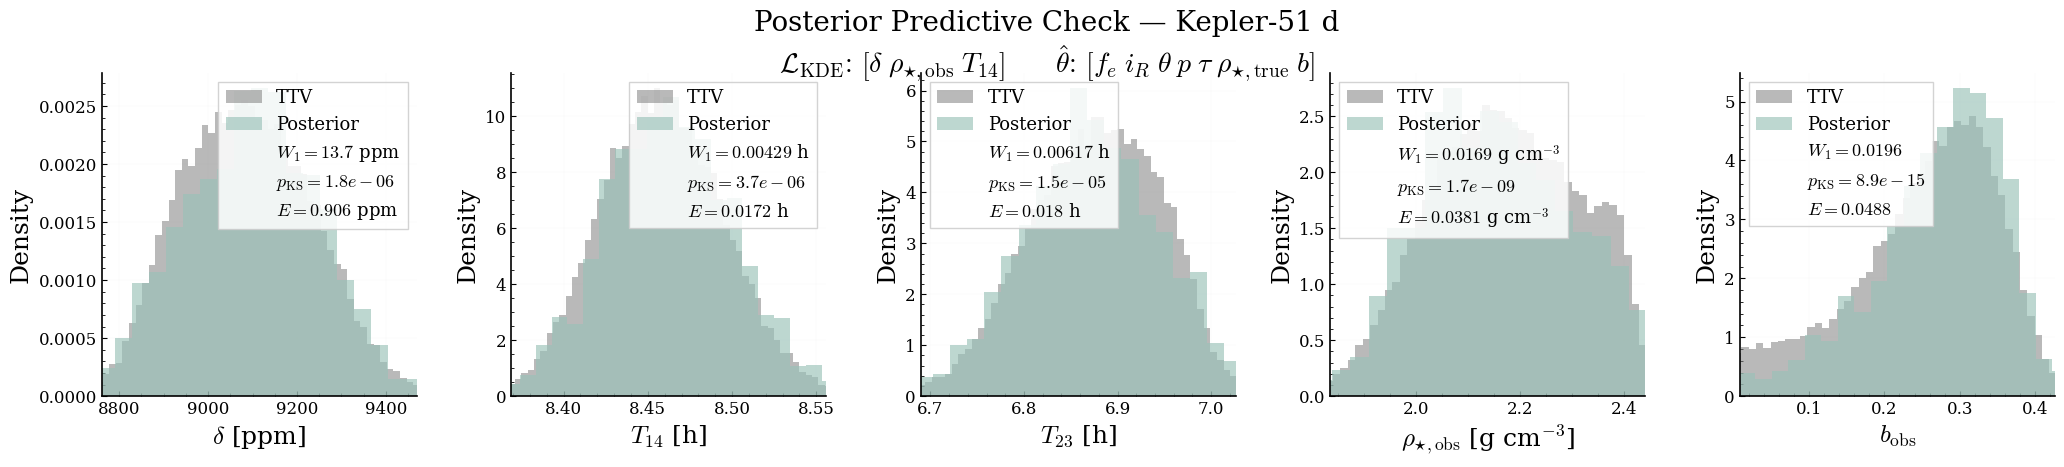

/home/numpaque/AppPR/pipeline/photoring/plotting.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/marginal/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_marginals.png


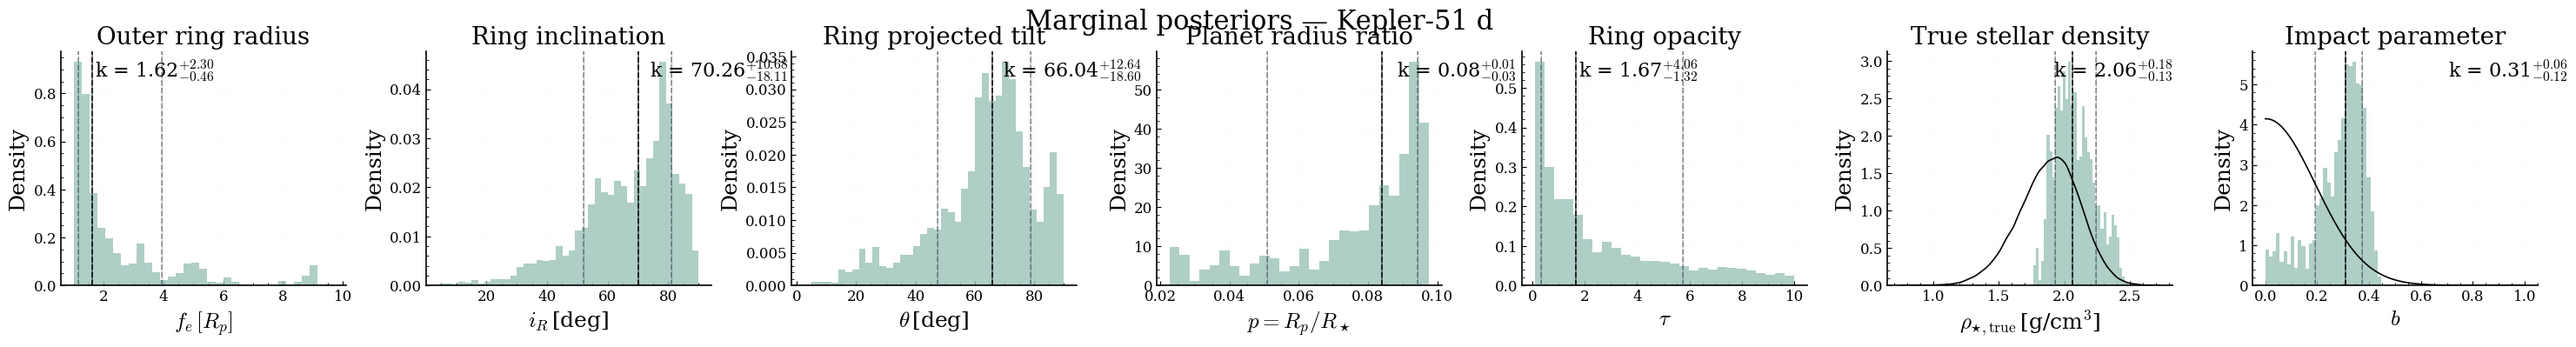

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/corner/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_corner.png


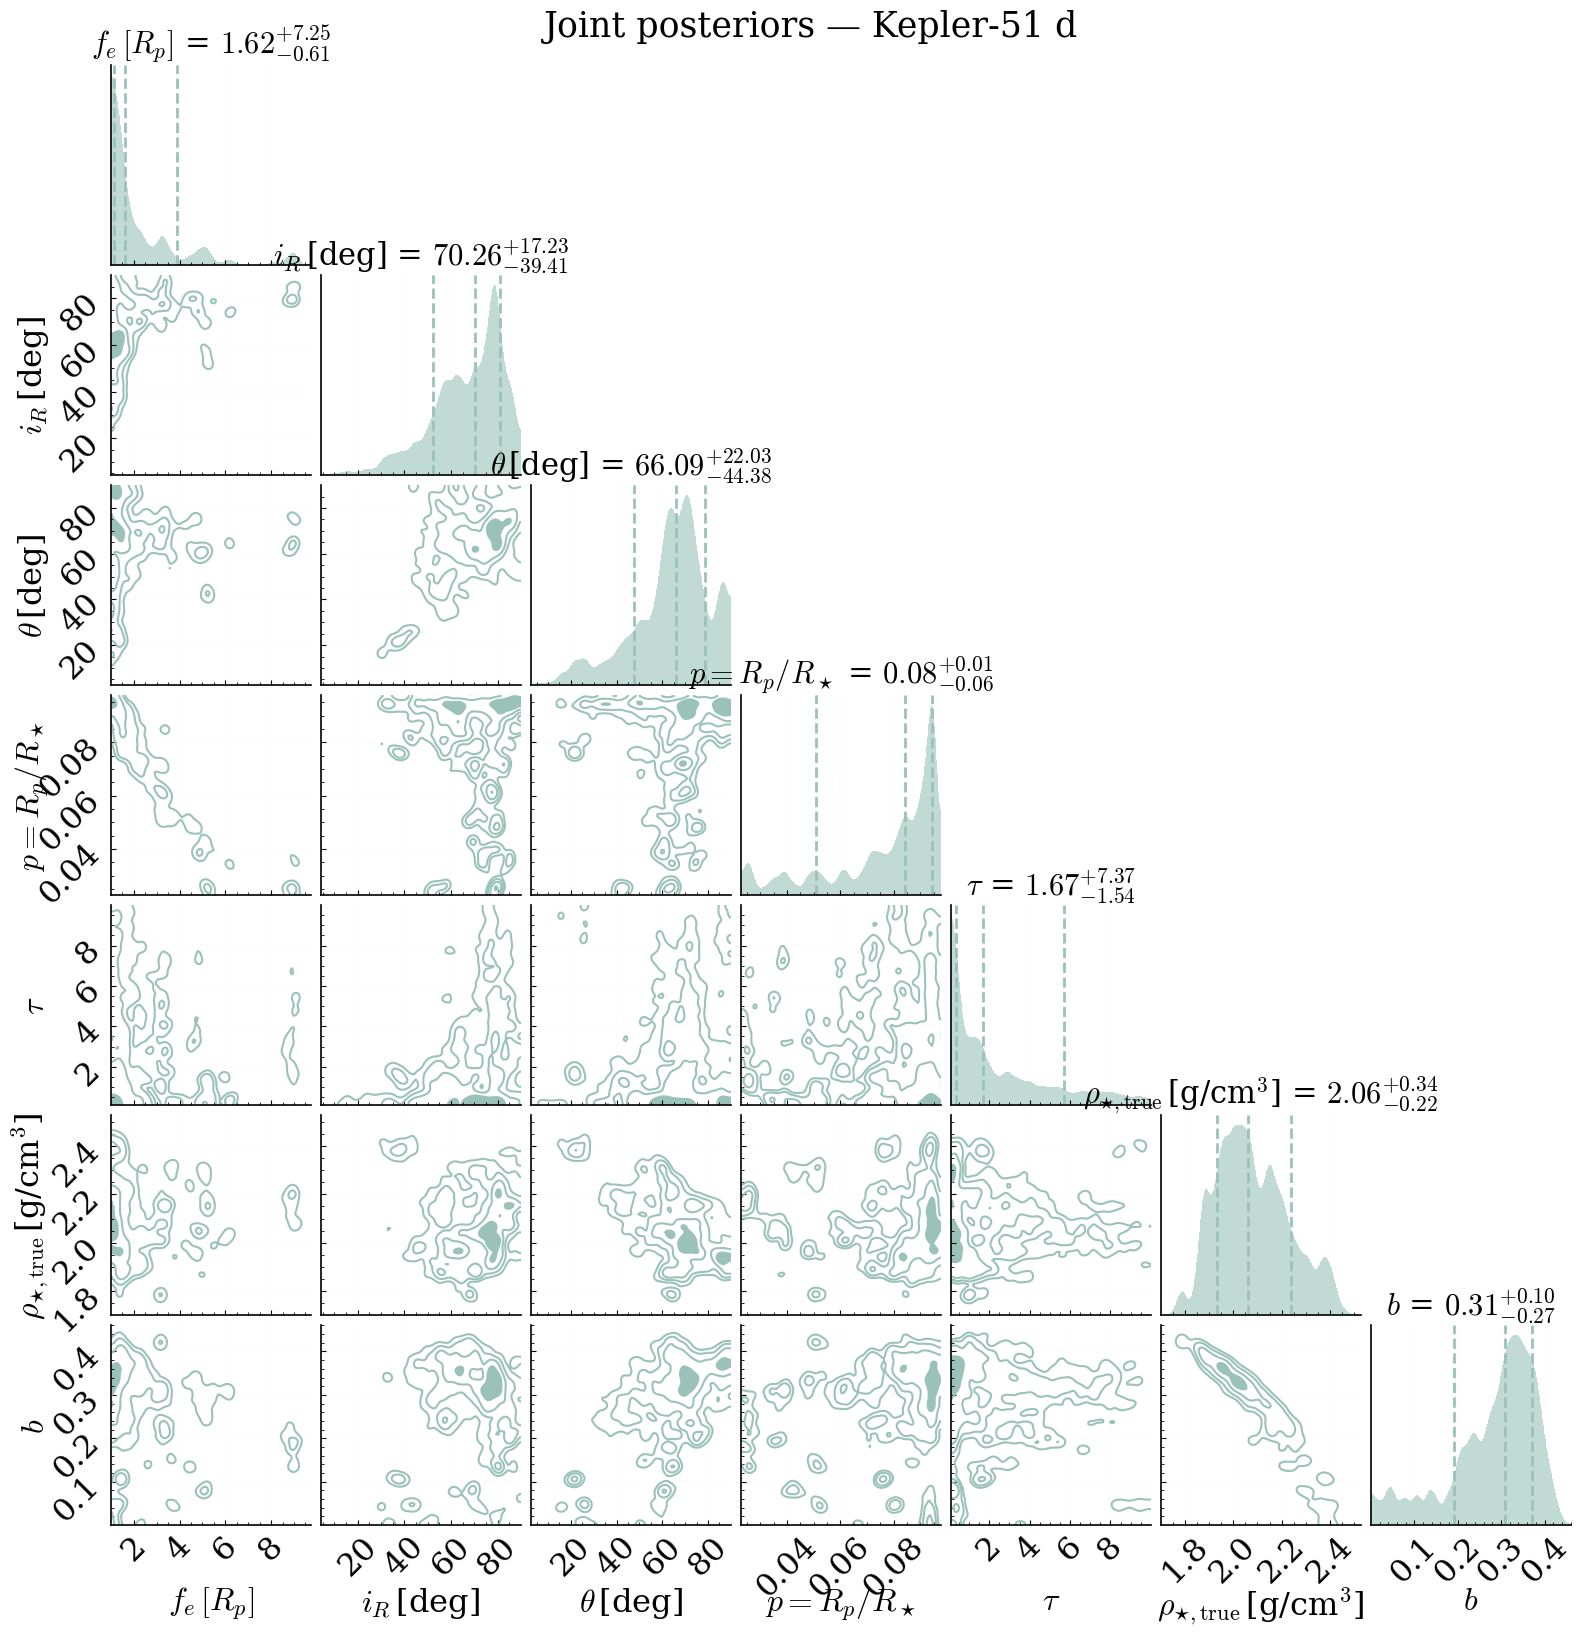

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/ring/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_ring.png


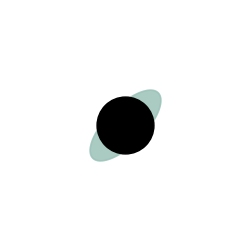


== kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE ==


/home/numpaque/AppPR/pipeline/photoring/plotting.py:546: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/ppc/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE_ppc.png


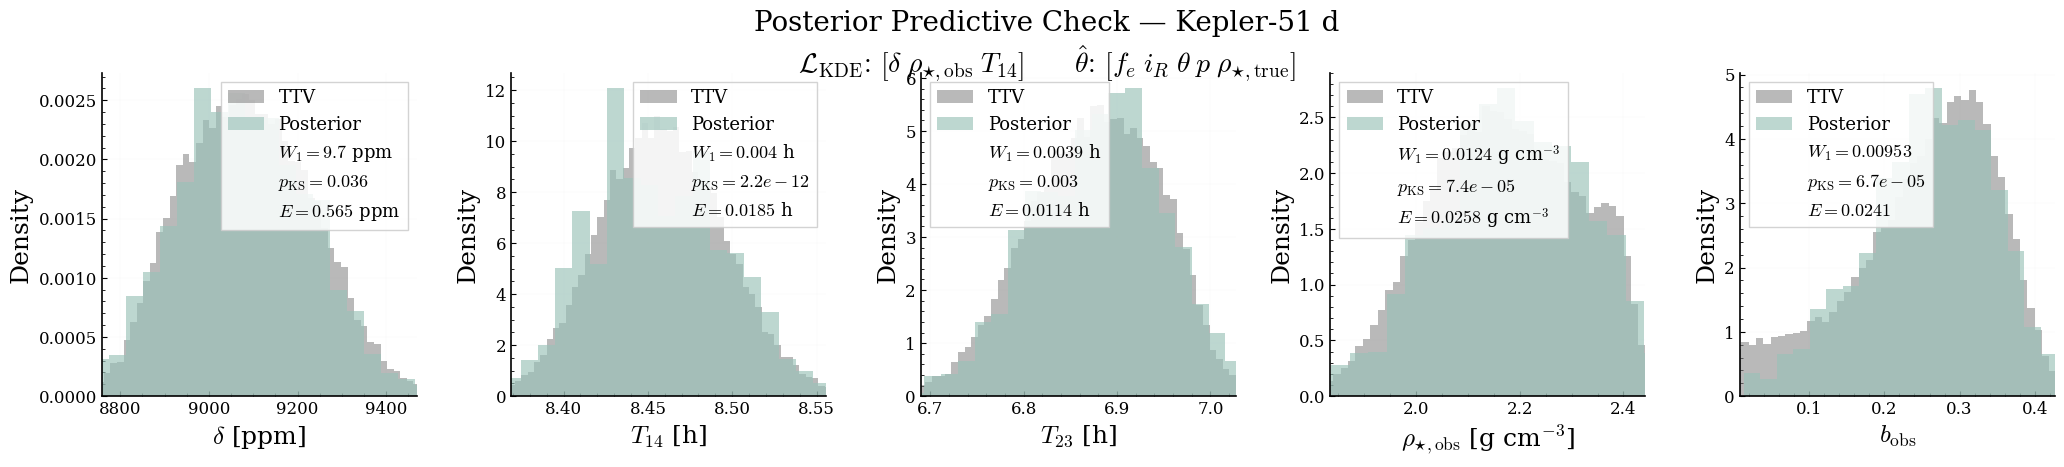

/home/numpaque/AppPR/pipeline/photoring/plotting.py:586: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/marginal/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE_marginals.png


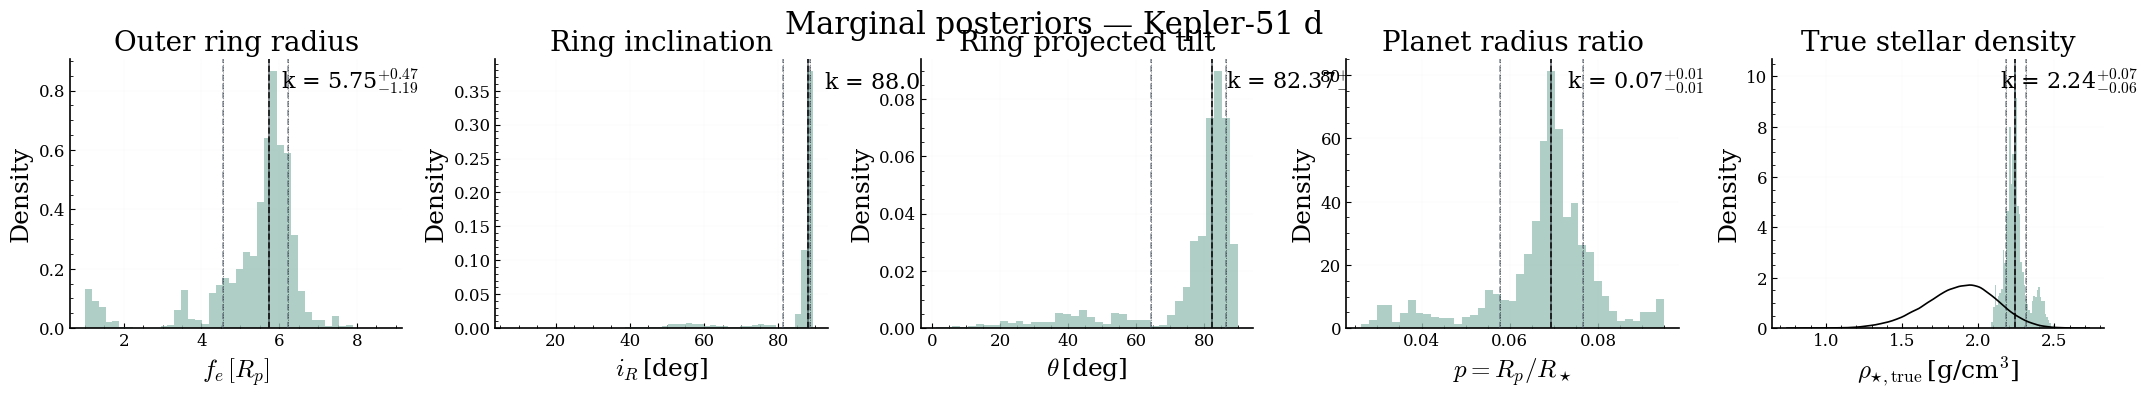

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/corner/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE_corner.png


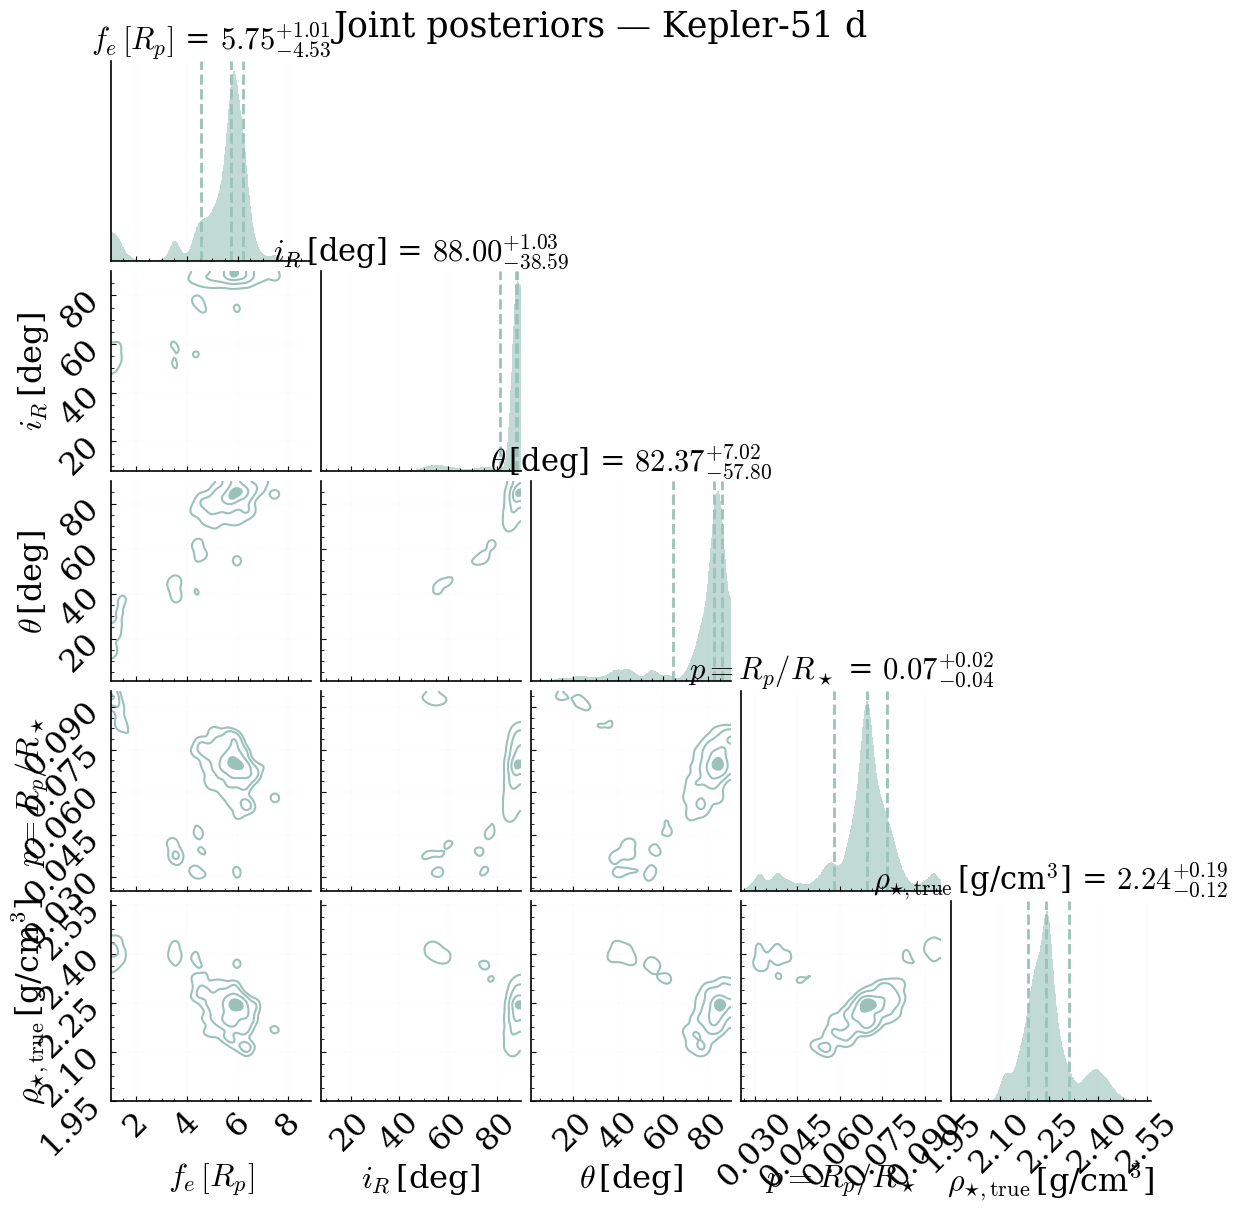

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/ring/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE_ring.png


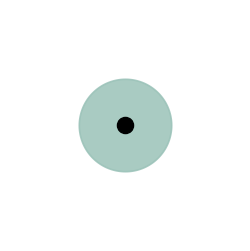

In [5]:
for r in RUNS_LIST:
    print(f"\n== {r['tag']} ==")
    ttv = TTV.get(r["planet"], {})
    if ttv:
        plot.plot_ppc(r, ttv, obs_keys=PPC_OBSERVABLES, paths=paths); plt.show()
    plot.plot_marginals(r, berger_rho=BERGER, paths=paths); plt.show()
    plot.plot_corner(r, paths=paths); plt.show()
    try:
        plot.plot_ring_diagram(r, paths=paths); plt.show()
    except Exception as e:
        print("  ring diagram skipped:", e)

## 4. Consolidated results panel (per run)

Two layouts:

- `plot_results_panel` — corner, ring diagram and the PPC row in one figure: the most complete
  single-page view of a run.
- `plot_results_panel_inset` — the square corner with the ring geometry inset in its free
  upper-right corner. This is the layout used in the manuscript.


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/panel/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_panel.png


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/panel/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE_panel.png


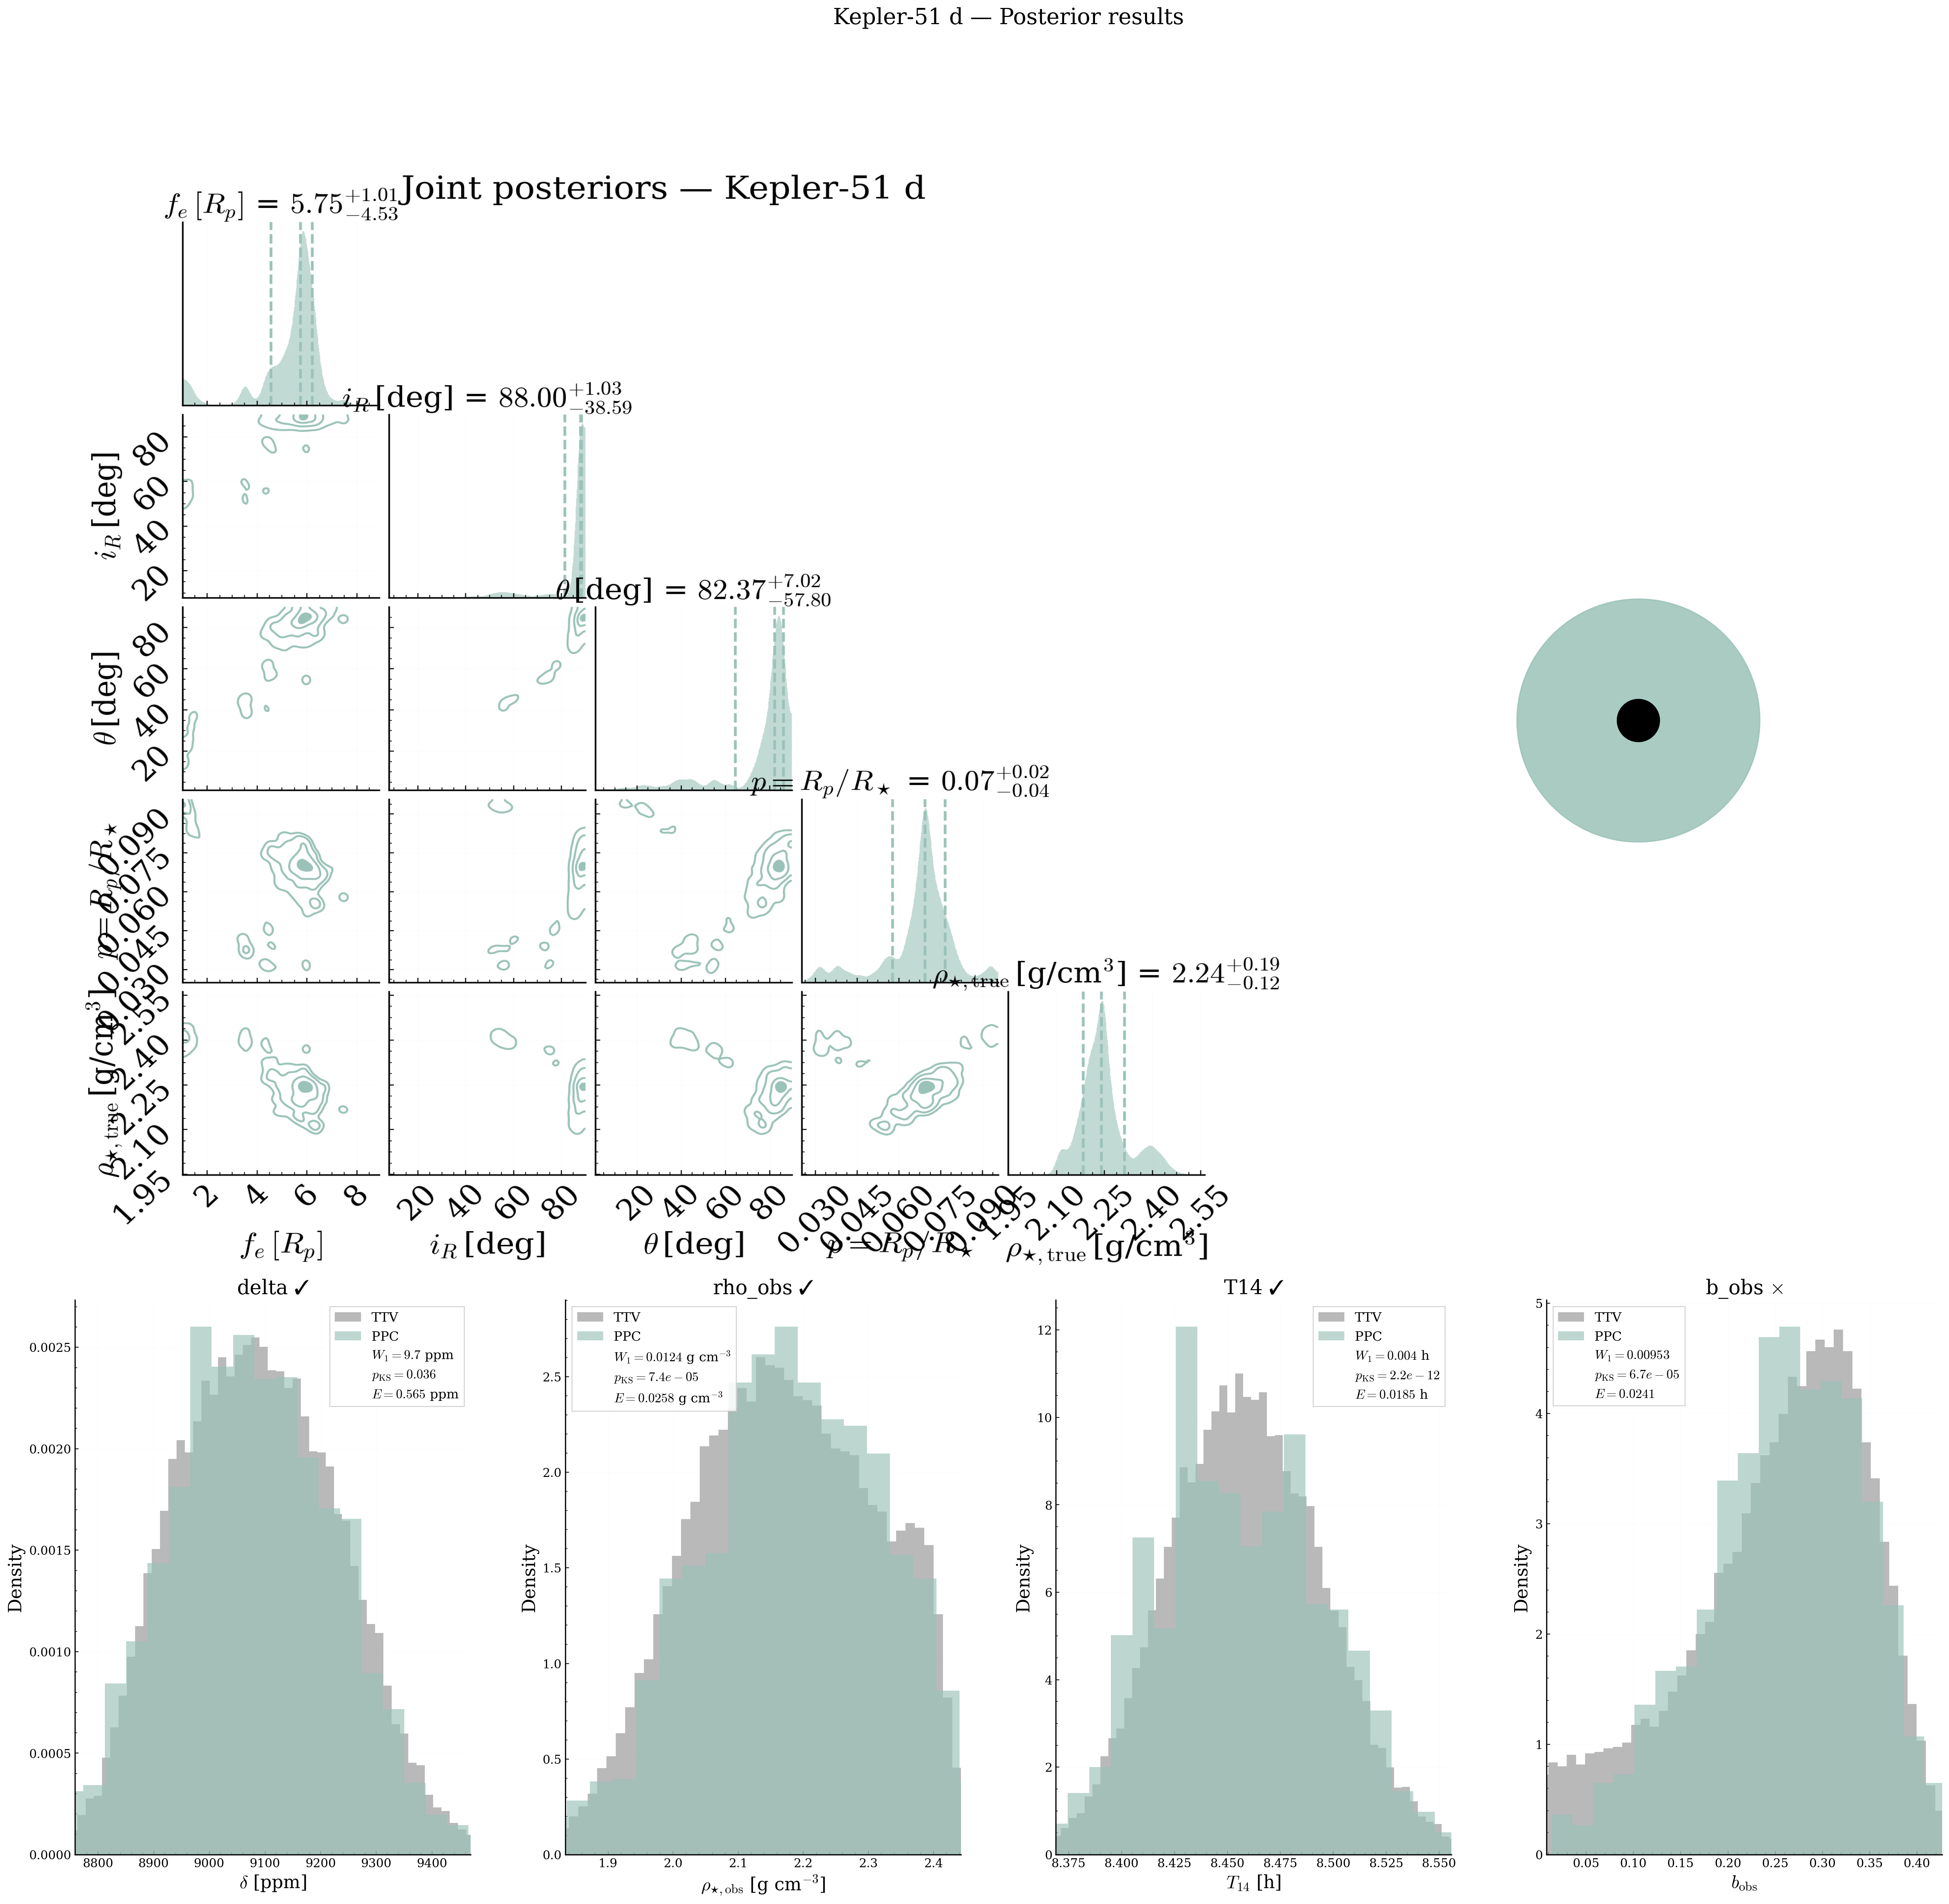

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/panel/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_panel_inset.png
  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/panel/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_pFREE_panel_inset.png


In [6]:
for r in RUNS_LIST:
    ttv = TTV.get(r["planet"], {})
    if not ttv:
        continue
    try:
        plot.plot_results_panel(r, ttv, obs_keys=["delta", "rho_obs", "T14", "b_obs"], paths=paths)
        plt.show()
    except Exception as e:
        print(f"  panel skipped for {r['tag']}:", e)

# The manuscript's layout: square corner with the ring geometry inset.
for _tag, _r in RUNS.items():
    try:
        _f = plot.plot_results_panel_inset(_r, paths=paths)
        plt.close(_f)
    except Exception as _e:
        print(f"  inset panel skipped for {_tag}: {_e}")


## 5. Summary tables

`print_summary_table` gives a readable median ± 68% table across runs; `print_latex_table`
emits the LaTeX bodies for the manuscript's result tables.


In [7]:
if RUNS_LIST:
    plot.print_summary_table(RUNS_LIST)
    print()
    plot.print_latex_table(RUNS_LIST)
else:
    print("No runs loaded — run step 2 first.")

Run tag                                   param      median      -err      +err        ln Z
kepler_51_d_NS_exorings_kde_delta-r          fe     1.62444   0.46445   2.30441       2.109
kepler_51_d_NS_exorings_kde_delta-r          ir    70.26002  18.11237  10.67622            
kepler_51_d_NS_exorings_kde_delta-r       theta    66.04285  18.60437  12.63792            
kepler_51_d_NS_exorings_kde_delta-r           p     0.08414   0.03327   0.01014            
kepler_51_d_NS_exorings_kde_delta-r         tau     1.67295   1.32486   4.06416            
kepler_51_d_NS_exorings_kde_delta-r    rho_true     2.06231   0.13047   0.17783            
kepler_51_d_NS_exorings_kde_delta-r           b     0.30884   0.11655   0.06306            
------------------------------------------------------------------------------------------------------------
kepler_51_d_NS_exorings_kde_delta-r          fe     5.74624   1.19166   0.46940       1.782
kepler_51_d_NS_exorings_kde_delta-r          ir    87.99610   6